In [8]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

In [9]:
env = gym.make("CliffWalking-v1")

action_space_size = env.action_space.n
state_space_size = env.observation_space.n

print(f"State Space Size: {state_space_size}")
print(f"Action Space Size: {action_space_size}")

State Space Size: 48
Action Space Size: 4


In [10]:
num_episodes = 10000
max_steps_per_episode = 100

learning_rate = 0.1
discount_rate = 0.99

max_exploration_rate = 1.0
min_exploration_rate = 0.01
exploration_decay_rate = 0.01

def choose_action(state, q_table, action_space_size, exploration_rate):
    if random.uniform(0, 1) < exploration_rate:
        action = env.action_space.sample()
    else:
        action = np.argmax(q_table[state, :])
    return action

In [11]:
#high const.
q_table_high_exp = np.zeros((state_space_size, action_space_size))
rewards_high_exp = []

constant_high_exploration_rate = 0.5

for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    rewards_current_episode = 0

    for step in range(max_steps_per_episode):
        action = choose_action(state, q_table_high_exp, action_space_size, constant_high_exploration_rate)

        new_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        q_table_high_exp[state, action] = q_table_high_exp[state, action] * (1 - learning_rate) + learning_rate * (reward + discount_rate * np.max(q_table_high_exp[new_state, :]))

        state = new_state
        rewards_current_episode += reward

        if done:
            break

    rewards_high_exp.append(rewards_current_episode)

In [12]:
#low const
q_table_low_exp = np.zeros((state_space_size, action_space_size))
rewards_low_exp = []

constant_low_exploration_rate = 0.05

for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    rewards_current_episode = 0

    for step in range(max_steps_per_episode):
        action = choose_action(state, q_table_low_exp, action_space_size, constant_low_exploration_rate)

        new_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        q_table_low_exp[state, action] = q_table_low_exp[state, action] * (1 - learning_rate) + learning_rate * (reward + discount_rate * np.max(q_table_low_exp[new_state, :]))

        state = new_state
        rewards_current_episode += reward

        if done:
            break

    rewards_low_exp.append(rewards_current_episode)

In [13]:
#decaying
q_table_decay_exp = np.zeros((state_space_size, action_space_size))
rewards_decay_exp = []

for episode in range(num_episodes):
    current_exploration_rate = min_exploration_rate + (max_exploration_rate - min_exploration_rate) * np.exp(-exploration_decay_rate * episode)

    state, info = env.reset()
    terminated = False
    truncated = False
    rewards_current_episode = 0

    for step in range(max_steps_per_episode):
        action = choose_action(state, q_table_decay_exp, action_space_size, current_exploration_rate)

        new_state, reward, terminated, truncated, info = env.step(action)

        q_table_decay_exp[state, action] = q_table_decay_exp[state, action] * (1 - learning_rate) + \
                                            learning_rate * (reward + discount_rate * np.max(q_table_decay_exp[new_state, :]))

        state = new_state
        rewards_current_episode += reward

        if terminated or truncated:
            break

    rewards_decay_exp.append(rewards_current_episode)
env.close()

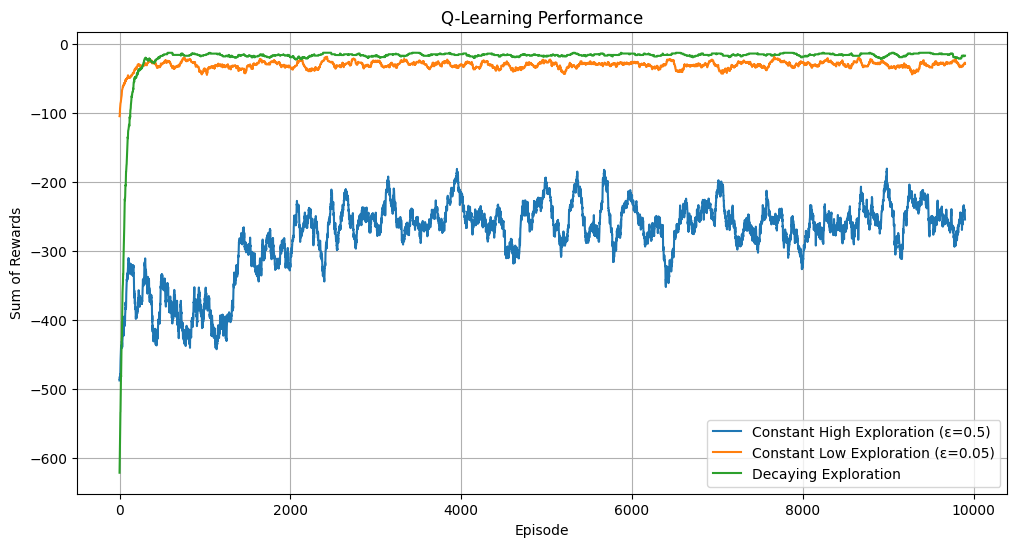

In [14]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size), 'valid') / window_size

plt.figure(figsize=(12, 6))

window_size = 100
smoothed_rewards_high_exp = moving_average(rewards_high_exp, window_size)
smoothed_rewards_low_exp = moving_average(rewards_low_exp, window_size)
smoothed_rewards_decay_exp = moving_average(rewards_decay_exp, window_size)

plt.plot(smoothed_rewards_high_exp, label='Constant High Exploration (ε=0.5)')
plt.plot(smoothed_rewards_low_exp, label='Constant Low Exploration (ε=0.05)')
plt.plot(smoothed_rewards_decay_exp, label='Decaying Exploration')

plt.xlabel('Episode')
plt.ylabel('Sum of Rewards')
plt.title('Q-Learning Performance')
plt.legend()
plt.grid(True)
plt.show()